# CatBoost scorecards

Upcoming addition to [**`xbooster`**](https://github.com/xRiskLab/xBooster) package.

Author: https://www.github.com/deburky

In [5]:
import pandas as pd
import catboost as cb
from sklearn.datasets import make_classification

# Step 1: Fit a CatBoost model
X, y = make_classification(n_samples=1000, n_features=5, random_state=42)
X = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
model = cb.CatBoostClassifier(iterations=10, depth=3, verbose=0)
model.fit(X, y)

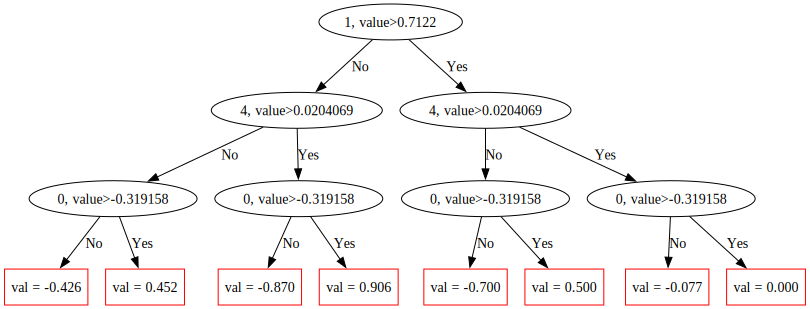

In [6]:
model.plot_tree(
    tree_idx=0
) # .render(filename='cb_tree', format='png')

In [7]:
# get available methods from cb_obj
cb_obj = model._object
tree_count = cb_obj._get_tree_count()
tree_leaf_count = cb_obj._get_tree_leaf_counts()
cb_depth = model.get_all_params()['depth']
print(f"Tree count: {tree_count}")
print(f"Tree leaf count: {tree_leaf_count}")
print(f"Tree depth: {2**cb_depth}")

Tree count: 10
Tree leaf count: [8 8 8 8 8 8 8 8 8 8]
Tree depth: 8


In [8]:
pool = cb.Pool(X, y)
cb_obj._get_tree_splits(0, pool)

['feature_0, bin=-0.319158',
 'feature_4, bin=0.0204069',
 'feature_1, bin=0.7122']

## CatBoost scorecards

Some resources used:

* [CatBoost - core.py](https://github.com/catboost/catboost/blob/master/catboost/python-package/catboost/core.py)
* [Extracting trees from GBM models as data frames](https://medium.com/@joachimiak.krzysztof/extracting-trees-from-gbm-models-as-data-frames-ce37f4c08ba6)

In [11]:
from catboost import CatBoostClassifier, Pool
from sklearn.datasets import make_classification

from catboost_scorecard import CatBoostScorecard

# Prepare data
X, y = make_classification(
    n_samples=1000, n_features=5, random_state=42, weights=[0.9, 0.1]
)
pool = Pool(X, y)

# Fit model
model = CatBoostClassifier(iterations=10, depth=3, verbose=0, allow_writing_files=False)
model.fit(pool)

# Run scorecard extraction
scorecard = CatBoostScorecard.extract(model, pool)

tree_idx = 0
print(len(scorecard.query("Tree == @tree_idx")))
display(scorecard.query("Tree == @tree_idx"))

8


,Tree,LeafIndex,Events,Count,NonEvents,LeafValue,Conditions,EventRate
0,0,0,29.0,33.0,4.0,0.556,1 <= -0.809576 AND 3 <= -0.216426 AND 1 <= -0....,0.878788
1,0,1,22.0,38.0,16.0,0.120,1 <= -0.809576 AND 3 <= -0.216426 AND 1 > -0.2...,0.578947
2,0,2,0.0,5.0,5.0,-0.294,1 <= -0.809576 AND 3 > -0.216426 AND 1 <= -0.2...,0.000000
3,0,3,2.0,80.0,78.0,-0.826,1 <= -0.809576 AND 3 > -0.216426 AND 1 > -0.26...,0.025000
4,0,4,0.0,0.0,0.0,0.000,1 > -0.809576 AND 3 <= -0.216426 AND 1 <= -0.2...,0.105000
5,0,5,16.0,38.0,22.0,-0.120,1 > -0.809576 AND 3 <= -0.216426 AND 1 > -0.26...,0.421053
6,0,6,0.0,0.0,0.0,0.000,1 > -0.809576 AND 3 > -0.216426 AND 1 <= -0.26...,0.105000
7,0,7,36.0,806.0,770.0,-0.897,1 > -0.809576 AND 3 > -0.216426 AND 1 > -0.264839,0.044665


In [12]:
df = scorecard.query("Tree == @tree_idx").copy()
df['avg'] = y.mean()
df['diff'] = df['avg'] - df['EventRate']
correlation = df[['LeafValue', 'diff']].corr(method='spearman').values[0, 1]
print(f"Spearman correlation: {correlation:.4f}")
df[['LeafValue', 'diff', 'EventRate']]

Spearman correlation: -0.8313


,LeafValue,diff,EventRate
0,0.556,-0.773788,0.878788
1,0.120,-0.473947,0.578947
2,-0.294,0.105000,0.000000
3,-0.826,0.080000,0.025000
4,0.000,0.000000,0.105000
5,-0.120,-0.316053,0.421053
6,0.000,0.000000,0.105000
7,-0.897,0.060335,0.044665


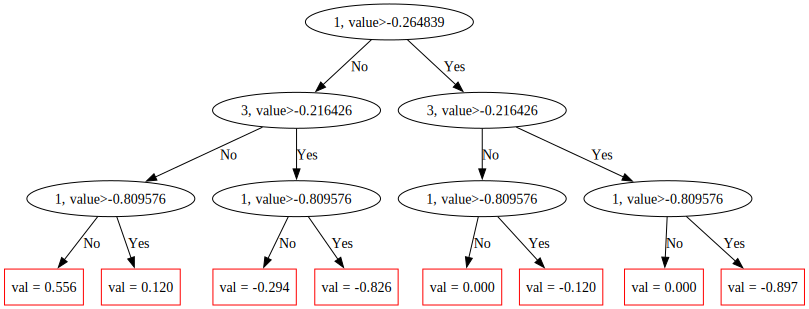

In [13]:
model.plot_tree(
    tree_idx=tree_idx
)

## Categorical features

In [14]:
from catboost import CatBoostClassifier, Pool
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np

from catboost_scorecard import CatBoostScorecard

# Generate data with categorical features
X, y = make_classification(
    n_samples=1000, 
    n_features=5, 
    random_state=42, 
    weights=[0.9, 0.1]
)

# Convert some features to categorical (strings for clarity)
X_df = pd.DataFrame(X, columns=[f"f_{i}" for i in range(X.shape[1])])
X_df["f_3"] = np.random.choice(["A", "B", "C"], size=len(X_df))  # Categorical
X_df["f_4"] = np.random.choice(["X", "Y"], size=len(X_df))      # Categorical

# Define categorical features
cat_features = ["f_3", "f_4"]

# Create Pool with categorical features
pool = Pool(
    data=X_df, 
    label=y,
    cat_features=cat_features
)

# Fit model
model = CatBoostClassifier(
    iterations=10,
    depth=3,
    verbose=0,
    cat_features=cat_features
)
model.fit(pool)

# Run scorecard extraction
scorecard = CatBoostScorecard.extract(model, pool)

# Inspect results
tree_idx = 0
print(f"Leaves in tree {tree_idx}: {len(scorecard.query('Tree == @tree_idx'))}")
display(scorecard.query("Tree == @tree_idx").head())

Leaves in tree 0: 8


,Tree,LeafIndex,Events,Count,NonEvents,LeafValue,Conditions,EventRate
0,0,0,6.0,143.0,137.0,-0.845,"f_0 <= 0.72399 AND f_4, value=X <= AND f_2 <= ...",0.041958
1,0,1,9.0,12.0,3.0,0.250,"f_0 <= 0.72399 AND f_4, value=X <= AND f_2 > -...",0.750000
2,0,2,6.0,131.0,125.0,-0.832,"f_0 <= 0.72399 AND f_4, value=X > AND f_2 <= -...",0.045802
3,0,3,13.0,14.0,1.0,0.462,"f_0 <= 0.72399 AND f_4, value=X > AND f_2 > -0...",0.928571
4,0,4,18.0,328.0,310.0,-0.859,"f_0 > 0.72399 AND f_4, value=X <= AND f_2 <= -...",0.054878


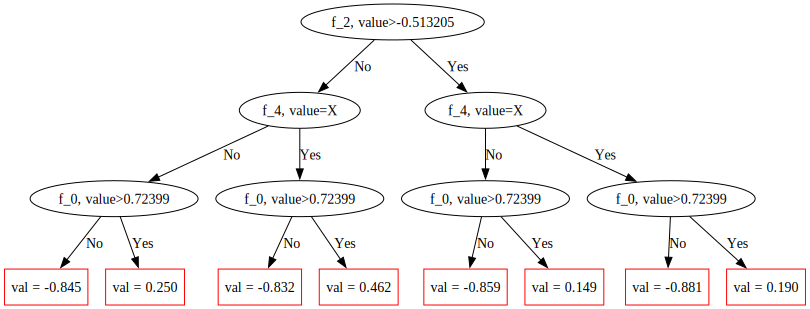

In [15]:
pool = Pool(X_df, y, cat_features=cat_features)
model.plot_tree(
    tree_idx=tree_idx,
    pool=pool,
)

## Text features

In [23]:
from faker import Faker
import pandas as pd

from catboost_scorecard import CatBoostScorecard

fake_text = Faker()

X_df = pd.DataFrame({
    "numerical_1": np.random.randn(1000),
    "numerical_2": np.random.randn(1000),
    "product_type": np.random.choice(["book", "movie", "music"], size=1000),
    "country": np.random.choice(["US", "UK", "JP"], size=1000),
    "description": [fake_text.text() * 10 for _ in range(1000)]
})

# Define categorical features (including text)
cat_features = ["product_type", "country", "description"]

# Create Pool and train model
pool = Pool(X_df, y, cat_features=cat_features, text_features=["description"])
model = CatBoostClassifier(iterations=10, depth=3, verbose=0)
model.fit(pool)

# Generate scorecard
scorecard = CatBoostScorecard.extract(model, pool)

# Show sample conditions
display(scorecard.query("Tree == 0").head())

,Tree,LeafIndex,Events,Count,NonEvents,LeafValue,Conditions,EventRate
0,0,0,105.0,997.0,892.0,-0.780,src_feature_id=0 calcer_id=15C8DA0F1BDE3191379...,0.105316
1,0,1,0.0,1.0,1.0,-0.077,src_feature_id=0 calcer_id=15C8DA0F1BDE3191379...,0.000000
2,0,2,0.0,1.0,1.0,-0.077,src_feature_id=0 calcer_id=15C8DA0F1BDE3191379...,0.000000
3,0,3,0.0,0.0,0.0,0.000,src_feature_id=0 calcer_id=15C8DA0F1BDE3191379...,0.105000
4,0,4,0.0,1.0,1.0,-0.077,src_feature_id=0 calcer_id=15C8DA0F1BDE3191379...,0.000000


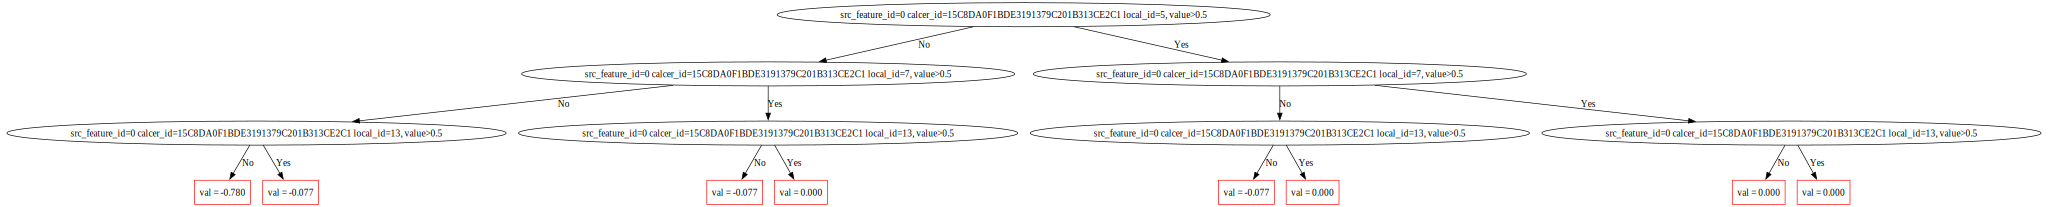

In [24]:
pool = Pool(X_df, y, cat_features=cat_features, text_features=["description"])
model.plot_tree(
    tree_idx=tree_idx,
    pool=pool,
)